# Patch-embedding analysis: rgb / rgbd_early / rgbd_dca (K=0,1,2)

Inspects what each variant does at the **very first layer** of the Swin backbone

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

torch.set_grad_enabled(False)
plt.rcParams['figure.dpi'] = 110

## Config

Points at the **Group C** runs (cosine schedule, full fine-tune, `--dca-lr-mult 5`,
`--epochs 200`) — the main result summarised in
[notebooks/k_fold_training_summary_ep200.ipynb](notebooks/k_fold_training_summary_ep200.ipynb).

These are 5-fold CV runs, so each variant has 5 fold dirs; we inspect a single
representative fold (`FOLD`, default `fold0`). Per fold we load the **best-by-AP**
checkpoint (highest `rob2pheno_fold_val/segm/AP`), auto-derived from `metrics.json` —
this matches the checkpoint the CV table reports, not `model_final.pth` (epoch 200,
past the overfit peak).

> **Weights must be on disk.** The fold dirs synced from HPC contain only
> `metrics.json`. Copy the best-by-AP `model_<iter>.pth` for each fold below from the
> HPC `output/` before running — the cell prints exactly which files it expects.

`type` is one of `rgb` / `early` / `dca`; `K` is the DCA iteration count.

In [ ]:
ROOT = Path('.').resolve()
DATA = ROOT / 'data' / 'Rob2Pheno'
RGB_DIR, DEPTH_DIR = DATA / 'RGB', DATA / 'Depth'
TRAIN_JSON, VAL_JSON = DATA / 'train_2class.JSON', DATA / 'val_2class.JSON'

# Group C (main result) fold to inspect. fold0..3 are mi6600; fold4 is mi6800.
FOLD = 'fold0of5_seed42'
MI = 'mi6600'                              # mi6800 if you switch to fold4
SELECT_METRIC = 'rob2pheno_fold_val/segm/AP'  # best-by-AP is chosen on the held-out fold

RUNS = {
    'rgb':            dict(dir=f'rgb_ep200_{MI}_ee10_0_cos_sz1280_{FOLD}_swin_tiny',                   type='rgb',   K=0),
    'rgbd_early':     dict(dir=f'rgbd_early_ep200_{MI}_ee10_0_cos_sz1280_{FOLD}_swin_tiny',            type='early', K=0),
    'rgbd_dca (K=0)': dict(dir=f'rgbd_dca_iter0_ep200_{MI}_ee10_0_cos_dlr5_0_sz1280_{FOLD}_swin_tiny', type='dca',   K=0),
    'rgbd_dca (K=1)': dict(dir=f'rgbd_dca_iter1_ep200_{MI}_ee10_0_cos_dlr5_0_sz1280_{FOLD}_swin_tiny', type='dca',   K=1),
    'rgbd_dca (K=2)': dict(dir=f'rgbd_dca_iter2_ep200_{MI}_ee10_0_cos_dlr5_0_sz1280_{FOLD}_swin_tiny', type='dca',   K=2),
}

def _best_ckpt(run_dir):
    """Filename of the best-by-AP checkpoint for a fold dir.

    Detectron2 names periodic checkpoints model_{iter:07d}.pth by the 0-based
    iteration, and (eval_period == checkpoint_period here) the best eval iteration
    has a matching checkpoint. Reads metrics.json to find the highest-AP eval.
    """
    best_it, best_ap = None, -1.0
    with (run_dir / 'metrics.json').open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            ap = r.get(SELECT_METRIC)
            if ap is not None and ap > best_ap:
                best_it, best_ap = r['iteration'], ap
    if best_it is None:
        raise RuntimeError(f'no {SELECT_METRIC} rows in {run_dir / "metrics.json"}')
    return f'model_{best_it:07d}.pth', best_it, best_ap

missing = []
for name, r in RUNS.items():
    d = ROOT / 'output' / r['dir']
    assert (d / 'metrics.json').exists(), f'missing metrics.json for {d} -- is the fold dir synced?'
    fname, it, ap = _best_ckpt(d)
    r['ckpt'] = d / fname
    print(f'{name:16s} best AP={ap:5.2f} @ iter {it:5d} -> {r["dir"]}/{fname}')
    if not r['ckpt'].exists():
        missing.append(r['ckpt'])

if missing:
    print('\nMISSING WEIGHTS - copy these best-by-AP .pth from the HPC output/ dir:')
    for m in missing:
        print('  ', m.relative_to(ROOT))
    raise FileNotFoundError(f'{len(missing)} checkpoint(s) absent (see above)')

# Must match training preprocessing. Mask2Former Swin uses INPUT.FORMAT='RGB'
# with ImageNet RGB-order pixel stats.
PIXEL_MEAN_RGB = np.array([123.675, 116.280, 103.530], dtype=np.float32)
PIXEL_STD_RGB  = np.array([58.395, 57.120, 57.375], dtype=np.float32)
MIN_SIZE_TEST, MAX_SIZE_TEST = 1024, 1280   # sz1280 training-time test resize
PATCH, EMBED_DIM = 4, 96
print('\ncheckpoints present for:', list(RUNS))

## Depth normalization stats

Replicates `_compute_depth_stats` from [variants/rgbd_early.py](variants/rgbd_early.py): mean/std over **valid** (non-zero) depth pixels of the **training-split** TIFFs. Zero is the sensor's invalid sentinel and is excluded.

> **Fold caveat.** Group C is 5-fold CV, so each fold trained on a different ~66-image
> partition (the `CV_SEED=42` KFold split) and therefore used slightly different depth
> mean/std. The stats below are over the **full 83-image** train split, so they differ
> marginally from what `fold0` actually trained with. The mismatch is small and only
> shifts the depth channel's normalization a touch — fine for the qualitative PCA/heatmaps
> here. For an exact forward pass, reproduce the fold's train indices and compute stats on
> those.

In [4]:
def _depth_path(rgb_name):
    return DEPTH_DIR / rgb_name.replace('_RGB.tiff', '_DEPTH.tiff')

def _train_depth_paths():
    coco = json.load(open(TRAIN_JSON))
    paths = [_depth_path(im['file_name']) for im in coco['images']]
    paths = sorted({p for p in paths if p.exists()})
    assert paths, 'no training depth tiffs found'
    return paths

def compute_depth_stats():
    s = sq = n = 0.0
    for p in _train_depth_paths():
        d = np.asarray(Image.open(p).convert('L'), dtype=np.float64)
        v = d[d > 0]
        s += v.sum(); sq += (v ** 2).sum(); n += v.size
    mean = s / n
    return float(mean), float(np.sqrt(sq / n - mean ** 2))

DEPTH_MEAN, DEPTH_STD = compute_depth_stats()
DEPTH_FILL = float(np.clip(round(DEPTH_MEAN), 0, 255))
print(f'depth: mean={DEPTH_MEAN:.3f} std={DEPTH_STD:.3f} fill={DEPTH_FILL:.0f}')

depth: mean=127.181 std=73.239 fill=127


## Preprocessing

Resize (shortest-edge, matching detectron2 `ResizeShortestEdge`), fill invalid depth, normalize per channel, pad to a multiple of the patch size. Returns the 4-channel input tensor plus display copies.

In [5]:
def _resize_dims(h, w):
    scale = MIN_SIZE_TEST / min(h, w)
    if max(h, w) * scale > MAX_SIZE_TEST:
        scale = MAX_SIZE_TEST / max(h, w)
    return round(h * scale), round(w * scale)

def load_input(rgb_name):
    rgb = np.asarray(Image.open(RGB_DIR / rgb_name).convert('RGB'), dtype=np.uint8)
    raw_depth = np.asarray(Image.open(_depth_path(rgb_name)).convert('L'), dtype=np.uint8)
    depth = np.where(raw_depth > 0, raw_depth, DEPTH_FILL).astype(np.uint8)
    h, w = rgb.shape[:2]
    nh, nw = _resize_dims(h, w)
    rgb_r = np.asarray(Image.fromarray(rgb).resize((nw, nh), Image.BILINEAR), dtype=np.float32)
    depth_r = np.asarray(Image.fromarray(depth).resize((nw, nh), Image.NEAREST), dtype=np.float32)
    rgb_n = (rgb_r - PIXEL_MEAN_RGB) / PIXEL_STD_RGB
    depth_n = (depth_r - DEPTH_MEAN) / DEPTH_STD
    x = np.concatenate([rgb_n, depth_n[..., None]], axis=-1)
    ph, pw = (-nh) % PATCH, (-nw) % PATCH
    x = np.pad(x, ((0, ph), (0, pw), (0, 0)))
    t = torch.from_numpy(x.transpose(2, 0, 1)).float().unsqueeze(0)  # (1,4,H,W)
    grid = (t.shape[-2] // PATCH, t.shape[-1] // PATCH)
    return t, rgb_r.astype(np.uint8), depth_r.astype(np.uint8), grid

## Reconstructed modules

`PatchEmbed` mirrors Mask2Former's Swin patch embed (conv + LayerNorm). `DCAFusion` is copied verbatim from [variants/rgbd_dca.py](variants/rgbd_dca.py) so the forward pass is identical to training. Trained weights are loaded into these from each checkpoint's `state_dict`.

In [6]:
class PatchEmbed(nn.Module):
    def __init__(self, in_chans, embed_dim=EMBED_DIM, patch=PATCH):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch, stride=patch)
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        x = self.proj(x)                    # B,C,Wh,Ww
        grid = (x.shape[2], x.shape[3])
        x = x.flatten(2).transpose(1, 2)    # B,N,C
        return self.norm(x), grid

class _IterBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        for n in ['W_Iq', 'W_Ik', 'W_Dv', 'W_Dq', 'W_Dk', 'W_Iv']:
            setattr(self, n, nn.Linear(d, d, bias=False))

class DCAFusion(nn.Module):
    def __init__(self, d=EMBED_DIM, num_iters=0):
        super().__init__()
        self.W_D1 = nn.Linear(d, d, bias=False)
        self.W_D2 = nn.Linear(d, d, bias=False)
        self.W_I1 = nn.Linear(d, d, bias=False)
        self.iter_blocks = nn.ModuleList([_IterBlock(d) for _ in range(num_iters)])
    def _attend(self, Qs, Ks, Vs, Wq, Wk, Wv, residual):
        Q, K, V = Wq(Qs).unsqueeze(1), Wk(Ks).unsqueeze(1), Wv(Vs).unsqueeze(1)
        return residual + F.scaled_dot_product_attention(Q, K, V).squeeze(1)
    def forward(self, rgb, depth):
        rgb = self._attend(depth, depth, rgb, self.W_D1, self.W_D2, self.W_I1, rgb)
        for b in self.iter_blocks:
            depth = self._attend(rgb, rgb, depth, b.W_Iq, b.W_Ik, b.W_Dv, depth)
            rgb = self._attend(depth, depth, rgb, b.W_Dq, b.W_Dk, b.W_Iv, rgb)
        return rgb, depth

In [7]:
def _load_sd(run):
    ck = torch.load(run['ckpt'], map_location='cpu')
    return ck.get('model', ck)

def _sub(sd, prefix):
    return {k[len(prefix):]: v for k, v in sd.items() if k.startswith(prefix)}

def build_modules(run):
    sd = _load_sd(run)
    m = {}
    if run['type'] in ('rgb', 'early'):
        pe = PatchEmbed(3 if run['type'] == 'rgb' else 4)
        pe.load_state_dict(_sub(sd, 'backbone.patch_embed.'))
        m['patch_embed'] = pe.eval()
    else:
        pr = PatchEmbed(3); pr.load_state_dict(_sub(sd, 'backbone.patch_embed_rgb.'))
        pd = PatchEmbed(1); pd.load_state_dict(_sub(sd, 'backbone.patch_embed_depth.'))
        fu = DCAFusion(EMBED_DIM, run['K']); fu.load_state_dict(_sub(sd, 'backbone.fusion.'))
        m.update(patch_embed_rgb=pr.eval(), patch_embed_depth=pd.eval(), fusion=fu.eval())
    return m

def extract(run, mods, t):
    # Returns the tokens that enter the Swin stages, plus DCA pre/post-fusion.
    if run['type'] in ('rgb', 'early'):
        x = t if run['type'] == 'early' else t[:, :3]
        tok, grid = mods['patch_embed'](x)
        return dict(tokens=tok, grid=grid)
    rgb_tok, grid = mods['patch_embed_rgb'](t[:, :3])
    depth_tok, _ = mods['patch_embed_depth'](t[:, 3:])
    fused_rgb, fused_depth = mods['fusion'](rgb_tok, depth_tok)
    return dict(tokens=fused_rgb, rgb_pre=rgb_tok, fused_rgb=fused_rgb, grid=grid)

MODELS = {name: build_modules(run) for name, run in RUNS.items()}
print('loaded modules for:', list(MODELS))

loaded modules for: ['rgb', 'rgbd_early', 'rgbd_dca (K=0)', 'rgbd_dca (K=1)', 'rgbd_dca (K=2)']


## Choose images

Default: first 3 validation images. Edit `IMAGE_NAMES` to pick specific ones.

In [10]:
val = json.load(open(VAL_JSON))
IMAGE_NAMES = [im['file_name'] for im in val['images']][:3]
print('\n'.join(IMAGE_NAMES))

RealSense_T20190528_234546_R04_P026480_H2300_A+000_RGB.tiff
RealSense_T20190528_230009_R02_P002860_H1630_A+000_RGB.tiff
RealSense_T20190528_230009_R02_P002860_H2300_A+000_RGB.tiff


Per-patch **relative depth contribution**, normalized so models are comparable:

- **early**: linear conv decomposition, `||conv(depth)|| / ||conv(rgb)||` per patch
  (the patch-embed conv is linear, so the depth channel's additive contribution is exact).
- **dca**: fusion delta, `||fused_rgb - rgb_pre|| / ||rgb_pre||` per patch
  (how much depth-guided cross-attention moved each RGB token off its RGB-only value).

Bright = strong depth influence.

In [ ]:
def early_depth_ratio(mods, t, grid):
    w = mods['patch_embed'].proj.weight
    rgb_c = F.conv2d(t[:, :3], w[:, :3], stride=PATCH)
    dep_c = F.conv2d(t[:, 3:], w[:, 3:4], stride=PATCH)
    return (dep_c.norm(dim=1) / (rgb_c.norm(dim=1) + 1e-6))[0].cpu().numpy()

def dca_delta_ratio(res):
    d = (res['fused_rgb'] - res['rgb_pre']).norm(dim=-1)
    r = res['rgb_pre'].norm(dim=-1) + 1e-6
    return (d / r).reshape(*res['grid']).cpu().numpy()

# Single image to display (self-contained; the multi-image cell below reuses
# the two ratio functions above).
img_name = IMAGE_NAMES[0]
t, rgb_disp, depth_disp, grid = load_input(img_name)

panel = [n for n in RUNS if RUNS[n]['type'] in ('early', 'dca')]
ncol = len(panel) + 1
fig, ax = plt.subplots(1, ncol, figsize=(3.0 * ncol, 3.4))
ax[0].imshow(rgb_disp); ax[0].set_title('RGB'); ax[0].axis('off')
for a, name in zip(ax[1:], panel):
    res = extract(RUNS[name], MODELS[name], t)
    if RUNS[name]['type'] == 'early':
        m = early_depth_ratio(MODELS[name], t, res['grid'])
    else:
        m = dca_delta_ratio(res)
    im = a.imshow(m, cmap='magma'); a.set_title(name, fontsize=9); a.axis('off')
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.02)
fig.suptitle(f'Relative depth contribution per patch  |  {img_name}')
plt.tight_layout(); plt.show()

Across several images

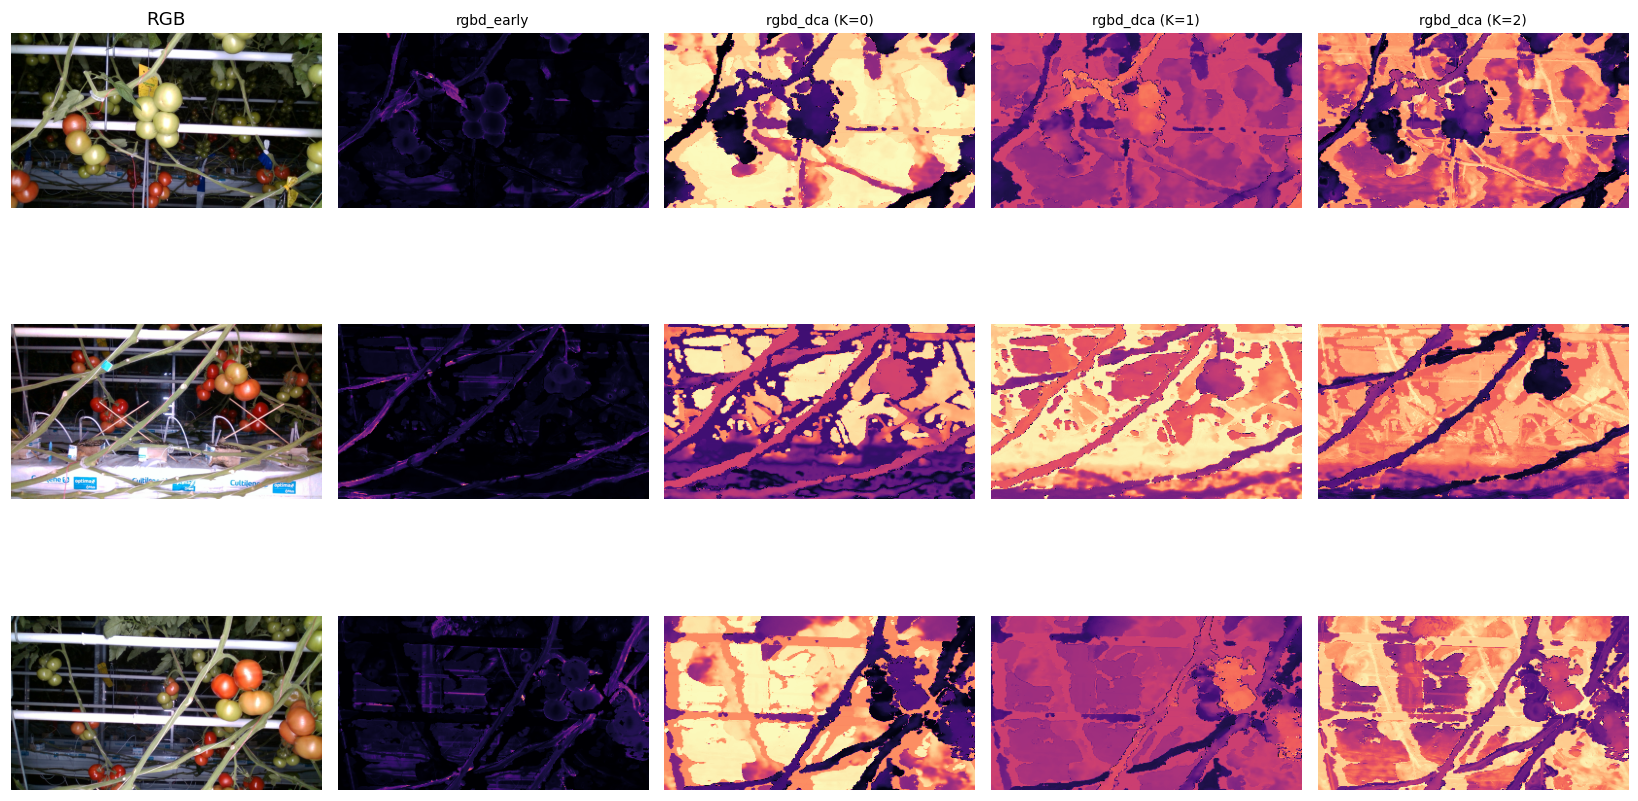

In [13]:
# Depth-influence per patch across images.
# early uses the conv ratio  ||conv(depth)||/||conv(rgb)||;
# dca uses the fusion delta  ||fused-rgb||/||rgb||.
# Each panel auto-scales independently, so read brightness WITHIN a column,
# not across the early vs dca boundary (different metrics).
panel_names = [n for n in RUNS if RUNS[n]['type'] in ('early', 'dca')]

def depth_influence(name, t):
    res = extract(RUNS[name], MODELS[name], t)
    if RUNS[name]['type'] == 'early':
        return early_depth_ratio(MODELS[name], t, res['grid'])
    return dca_delta_ratio(res)

fig, ax = plt.subplots(len(IMAGE_NAMES), len(panel_names) + 1,
                       figsize=(3.0 * (len(panel_names) + 1), 3.0 * len(IMAGE_NAMES)))
ax = np.atleast_2d(ax)
for ri, nm in enumerate(IMAGE_NAMES):
    ti, rgb_i, _, gi = load_input(nm)
    ax[ri, 0].imshow(rgb_i); ax[ri, 0].axis('off')
    if ri == 0: ax[ri, 0].set_title('RGB')
    for ci, name in enumerate(panel_names, start=1):
        im = ax[ri, ci].imshow(depth_influence(name, ti), cmap='magma')
        ax[ri, ci].axis('off')
        if ri == 0: ax[ri, ci].set_title(name, fontsize=9)
#fig.suptitle('Relative depth influence per patch  (early: conv ratio | dca: fusion delta)')
plt.tight_layout(); plt.show()